# Interactive Denoising Lab — PandaOmron

Experiment with GR00T N1.6's flow-matching denoising loop using
`ROBOCASA_PANDA_OMRON` observations captured from the simulator.

PandaOmron uses **EEF delta** actions, so the 3D plots show true Cartesian
end-effector trajectories.

## Prerequisites

Before running this notebook, capture at least one observation `.npz` file
using `interactive_rollout.py`:

```bash
# Terminal 1 (model venv)
uv run python gr00t/eval/run_gr00t_server.py \
  --model-path nvidia/GR00T-N1.6-3B \
  --embodiment-tag ROBOCASA_PANDA_OMRON \
  --use-sim-policy-wrapper

# Terminal 2 (sim venv)
gr00t/eval/sim/robocasa/robocasa_uv/.venv/bin/python \
  scripts/denoising_lab/eval/interactive_rollout.py \
  --env-name robocasa_panda_omron/OpenDrawer_PandaOmron_Env \
  --host 127.0.0.1 --port 5555 \
  --n-action-steps 8 --max-episode-steps 400 \
  --save-dir /tmp/saved_observations
```

Then press `o` in the interactive rollout to save an observation, and set
`OBS_PATH` below to the saved `.npz` file.

In [111]:
# Cell 1: Imports + config
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.denoising_lab.denoising_lab import (
    DenoisingLab, TrajectoryVisualizer, compare_strategies,
)

MODEL_PATH = "nvidia/GR00T-N1.6-3B"
EMBODIMENT_TAG = "robocasa_panda_omron"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Path to observation .npz captured by interactive_rollout.py
OBS_PATH = "/home/ubuntu/results/npz_save_OpenDrawer_baseline_euler/ep000_step020.npz"

print(f"Device: {DEVICE}")

Device: cuda


In [2]:
# Cell 2: Load model
lab = DenoisingLab(MODEL_PATH, EMBODIMENT_TAG, device=DEVICE)
print(f"Model loaded. Action horizon: {lab.action_horizon}, Action dim: {lab.action_dim}")
print(f"Inference timesteps: {lab.num_inference_timesteps}, Timestep buckets: {lab.num_timestep_buckets}")

/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/ubuntu/my_Isaac-GR00T/.venv/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Tune backbone llm: False
Tune backbone visual: False
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.v_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.o_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.gate_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.up_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.down_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.input_layernorm.weight
Backbone trainable parameter: model.language_mode

/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:205: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'compute_dtype' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.compute_dtype'.
  embedding_dim=self.inner_dim, compute_dtype=self.compute_dtype
/home/ubuntu/my_Isaac-GR00T/gr00t/model/modules/dit.py:236: FutureWarning: Accessing config attribute `output_dim` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'output_dim' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.output_dim'.
  self.proj_out_2 = nn.Linear(self.inner_dim, self.output_dim)
`use_fast` is set to `True` but the image processor class does not have a fast version.  Falling back to the slow version.


Tune action head projector: True
Tune action head diffusion model: True
Tune action head vlln: True


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.56it/s]


Model loaded. Action horizon: 50, Action dim: 128
Inference timesteps: 4, Timestep buckets: 1000


In [15]:
# Cell 3: Load observation from .npz saved by interactive_rollout.py
obs = DenoisingLab.load_observation(OBS_PATH)
print("Observation loaded from:", OBS_PATH)
print("Keys:", list(obs.keys()))
for k, v in obs.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: {v}")

Observation loaded from: /home/ubuntu/results/npz_save_OpenDrawer_baseline_euler/ep000_step017.npz
Keys: ['state.base_position', 'state.base_rotation', 'state.end_effector_position_absolute', 'state.end_effector_position_relative', 'state.end_effector_rotation_absolute', 'state.end_effector_rotation_relative', 'state.gripper_qpos', 'state.gripper_qvel', 'state.joint_position', 'state.joint_position_cos', 'state.joint_position_sin', 'state.joint_velocity', 'video.res256_image_side_0', 'video.res256_image_side_1', 'video.res256_image_wrist_0', 'video.res512_image_side_0', 'video.res512_image_side_1', 'video.res512_image_wrist_0', 'annotation.human.action.task_description']
  state.base_position: shape=(1, 1, 3), dtype=float32
  state.base_rotation: shape=(1, 1, 4), dtype=float32
  state.end_effector_position_absolute: shape=(1, 1, 3), dtype=float32
  state.end_effector_position_relative: shape=(1, 1, 3), dtype=float32
  state.end_effector_rotation_absolute: shape=(1, 1, 4), dtype=float32

In [16]:
# Cell 4
print("Command to VLA: ")
print(obs["annotation.human.action.task_description"])

Command to VLA: 
('open the left drawer',)


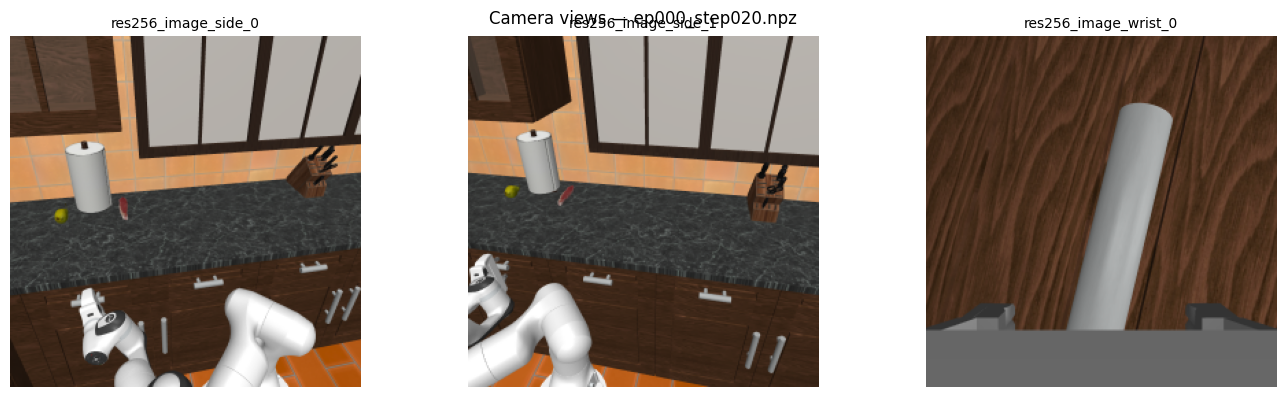

In [116]:
# Cell 5: Visualize camera views from the saved observation
# Shows what the robot sees — helps identify which .npz to experiment with
fig = DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
plt.suptitle(f"Camera views — {OBS_PATH.split('/')[-1]}", fontsize=12)
plt.show()

In [117]:
# Cell 6: Encode backbone features (EXPENSIVE — run once)
features = lab.encode_features_from_sim_obs(obs)
print(f"Backbone features: {features.backbone_features.shape}")
print(f"State features: {features.state_features.shape}")
print(f"Embodiment ID: {features.embodiment_id}")

Backbone features: torch.Size([1, 284, 2048])
State features: torch.Size([1, 1, 1536])
Embodiment ID: tensor([13], device='cuda:0')


In [118]:
# Cell 7: Default denoising (4-step flow matching)
result = lab.denoise(features, seed=42)
print(f"Final action shape: {result.action_pred.shape}")
print(f"Seed: {result.seed}")
for info in result.intermediates:
    print(f"  Step {info.step}: t_cont={info.t_cont:.3f} t_disc={info.t_discretized} "
          f"action_norm={info.action_norm:.4f} velocity_norm={info.velocity_norm:.4f}")

Final action shape: torch.Size([1, 50, 128])
Seed: 42
  Step 0: t_cont=0.000 t_disc=0 action_norm=77.7739 velocity_norm=30.7057
  Step 1: t_cont=0.250 t_disc=250 action_norm=77.1853 velocity_norm=31.2027
  Step 2: t_cont=0.500 t_disc=500 action_norm=77.4565 velocity_norm=31.9268
  Step 3: t_cont=0.750 t_disc=750 action_norm=78.6248 velocity_norm=32.8372


In [119]:
# Cell 8: Decode + inspect actions
decoded = lab.decode_raw_actions(result.action_pred, features.states)
print("Decoded action keys (PandaOmron EEF):")
for key, arr in decoded.items():
    print(f"  {key}: shape={arr.shape}")

for t in range(min(3, list(decoded.values())[0].shape[1])):
    print(lab.label_action_step(decoded, t))

Decoded action keys (PandaOmron EEF):
  end_effector_position: shape=(1, 16, 3)
  end_effector_rotation: shape=(1, 16, 3)
  gripper_close: shape=(1, 16, 1)
  base_motion: shape=(1, 16, 4)
  control_mode: shape=(1, 16, 1)
Step 0:
  end_effector_position: [+0.3047 +0.1875 -0.1963]
  end_effector_rotation: [+0.0039 -0.0371 -0.0020]
  gripper_close: [+0.0020]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]
Step 1:
  end_effector_position: [+0.3027 +0.1572 -0.2070]
  end_effector_rotation: [+0.0156 -0.0156 -0.0137]
  gripper_close: [+0.0039]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]
Step 2:
  end_effector_position: [+0.2969 +0.1377 -0.2168]
  end_effector_rotation: [+0.0029 -0.0225 +0.0000]
  gripper_close: [+0.0039]
  base_motion: [+0.0000 +0.0000 +0.0000 +0.0000]
  control_mode: [+0.0000]


Plotting EEF trajectory using key: 'end_effector_position'


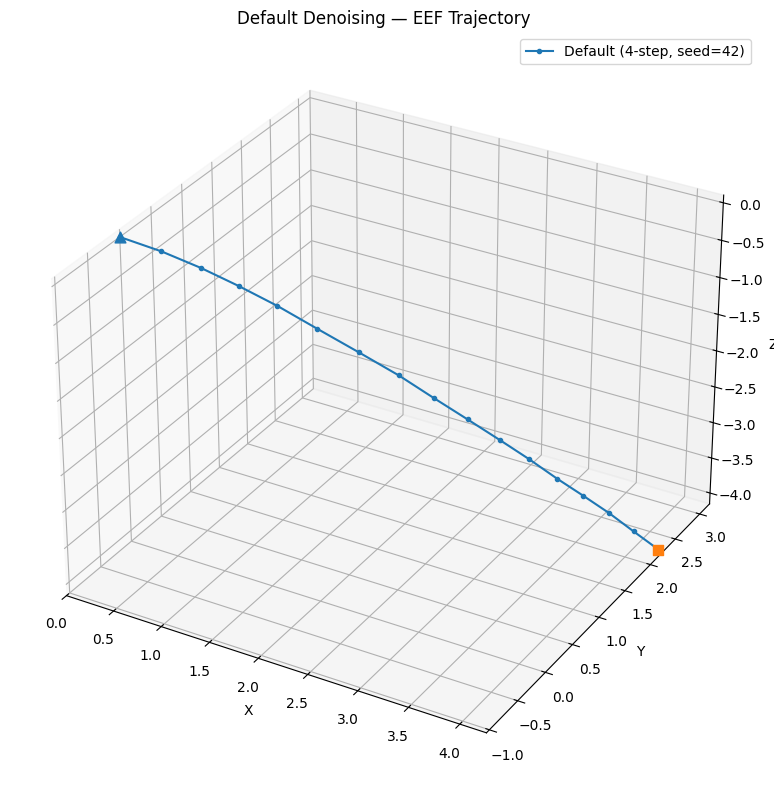

In [120]:
# Cell 9: 3D EEF trajectory plot
EEF_KEY = "end_effector_position"
print(f"Plotting EEF trajectory using key: '{EEF_KEY}'")

viz = TrajectoryVisualizer()
viz.add_trajectory(decoded, "Default (4-step, seed=42)", eef_key=EEF_KEY)
fig = viz.plot_eef_3d(title="Default Denoising — EEF Trajectory")
plt.show()

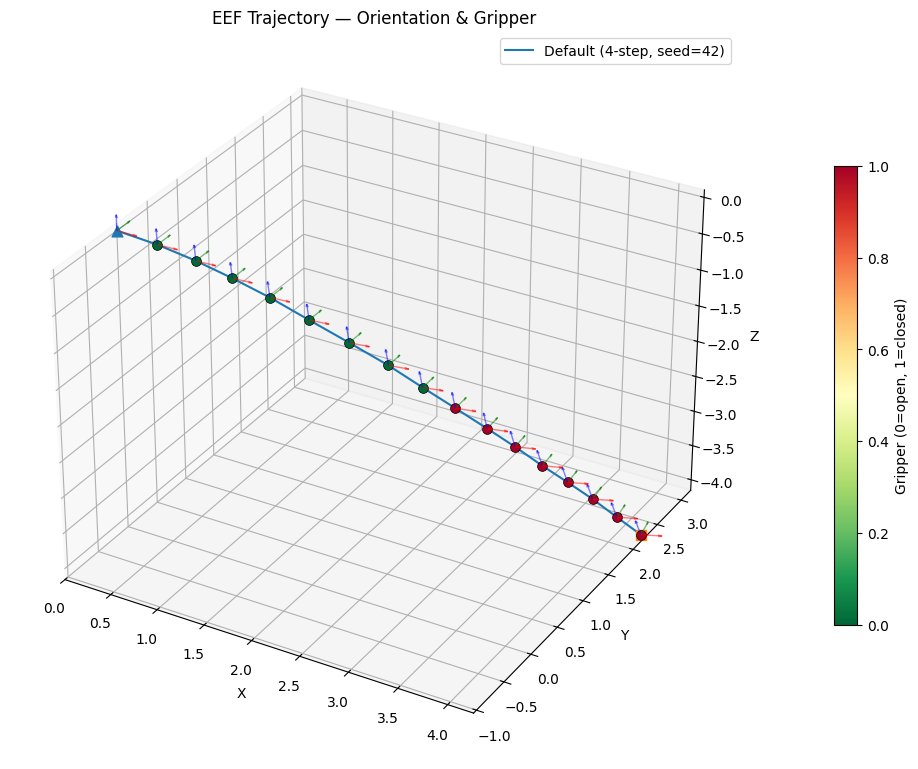

In [121]:
# Cell 10: 3D EEF trajectory with orientation frames and gripper state
# Same trajectory as above, but with mini RGB coordinate frames (R=X, G=Y,
# B=Z) showing accumulated EEF orientation from axis-angle deltas, and
# green→red coloured markers for gripper state (green=open, red=closed).
#
# Toggle show_orientation / show_gripper to enable/disable independently.
# frame_stride controls how often orientation frames are drawn (1=every step).

viz_full = TrajectoryVisualizer()
viz_full.add_trajectory(decoded, "Default (4-step, seed=42)", eef_key=EEF_KEY)

fig = viz_full.plot_eef_3d(
    title="EEF Trajectory — Orientation & Gripper",
    show_orientation=True,
    show_gripper=True,
)
plt.show()

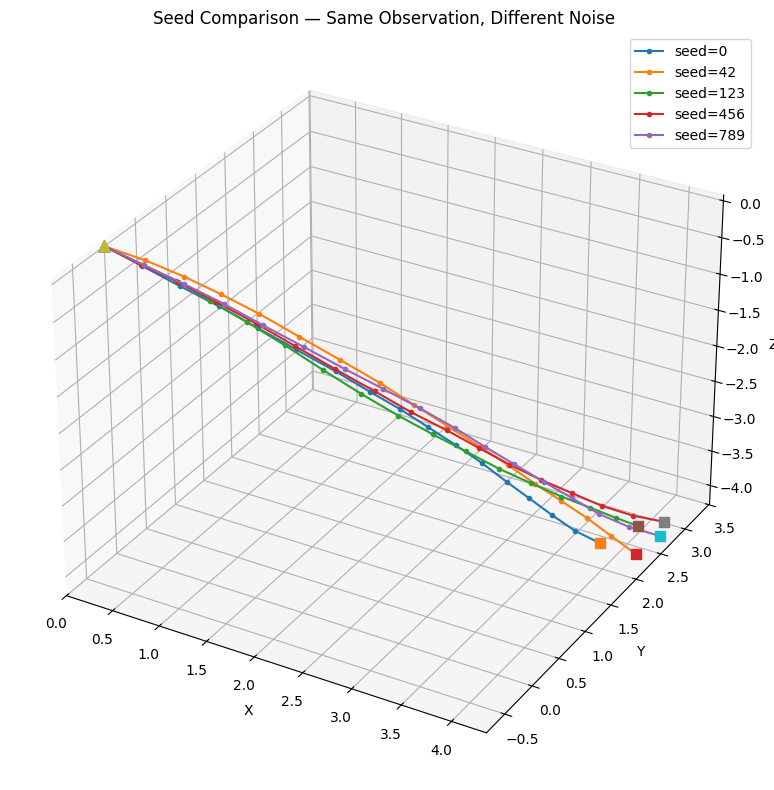

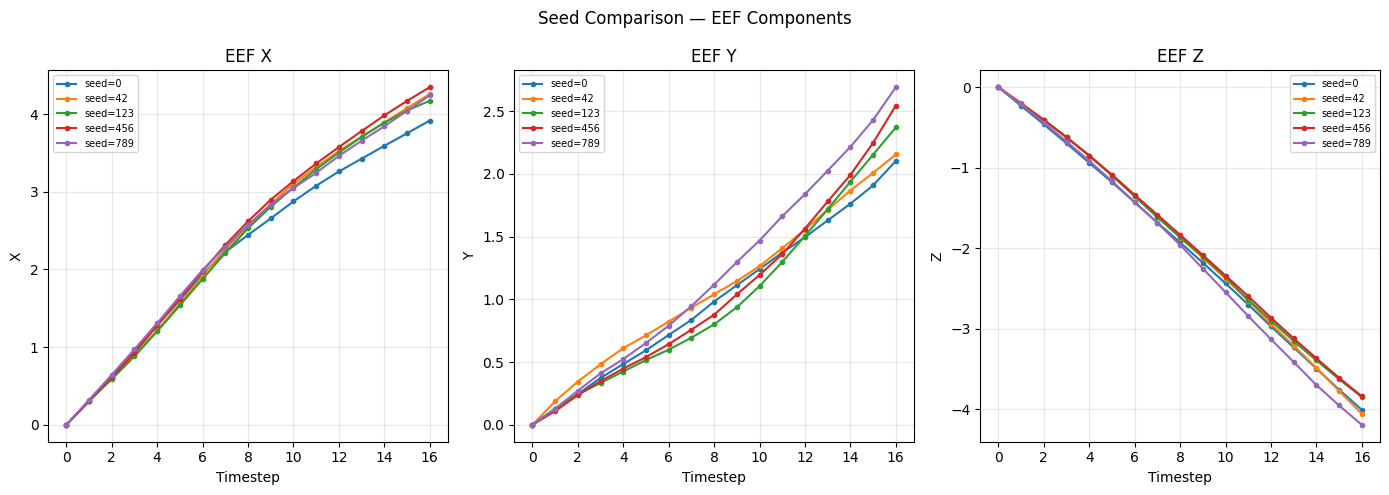

In [122]:
# Cell 11: Compare seeds — 5 different seeds on the same 3D plot
viz_seeds = TrajectoryVisualizer()
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

for i, seed in enumerate([0, 42, 123, 456, 789]):
    r = lab.denoise(features, seed=seed)
    d = lab.decode_raw_actions(r.action_pred, features.states)
    viz_seeds.add_trajectory(d, f"seed={seed}", color=colors[i], eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Seed Comparison — Same Observation, Different Noise")
plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()

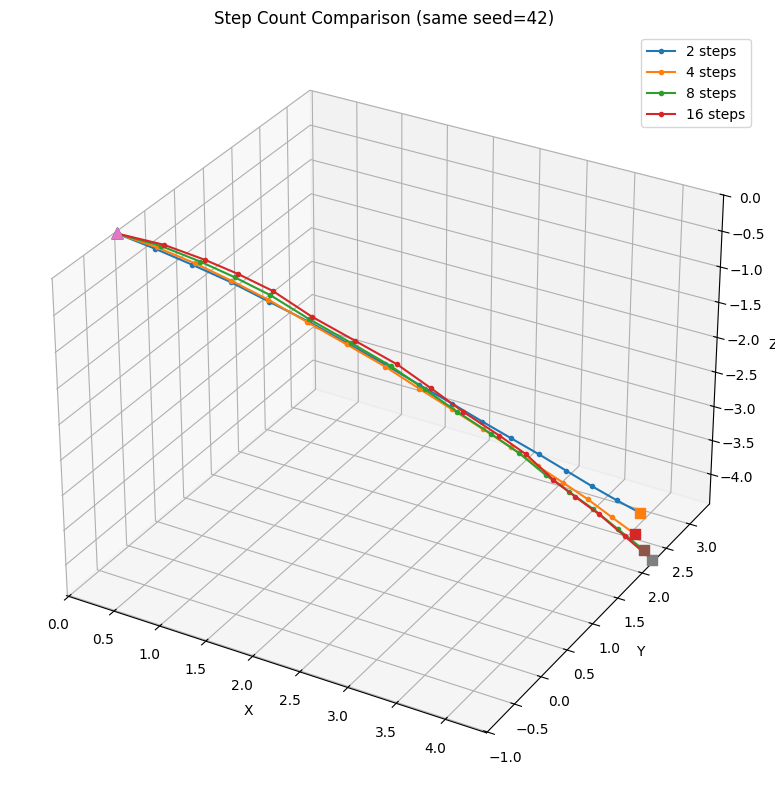

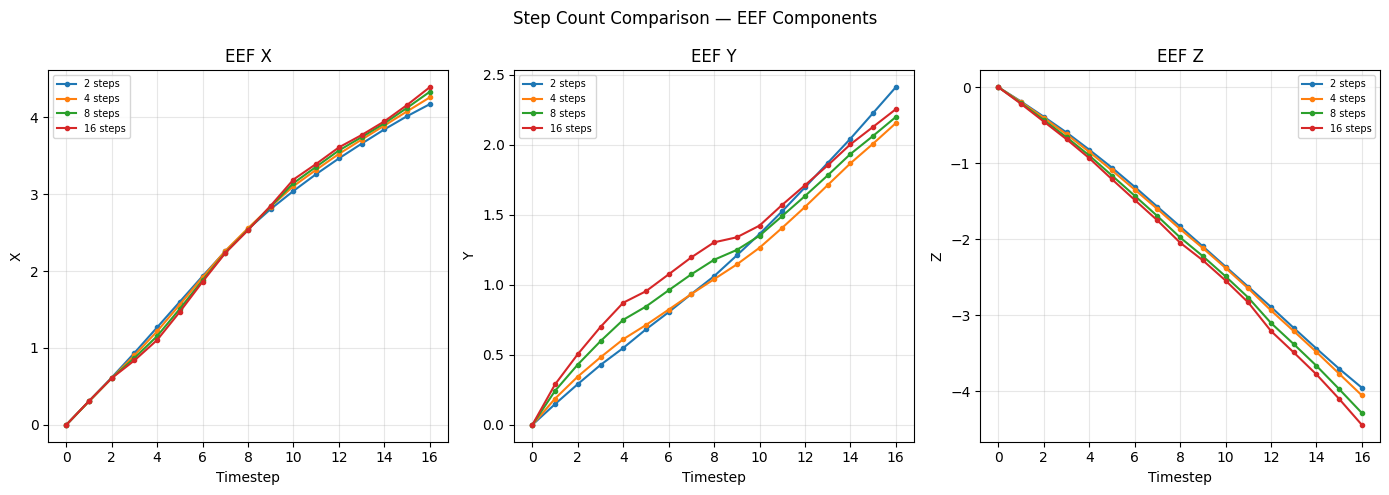

In [123]:
# Cell 12: Compare step counts — 2/4/8/16 denoising steps
strategies = [
    {"num_steps": 2, "seed": 42},
    {"num_steps": 4, "seed": 42},
    {"num_steps": 8, "seed": 42},
    {"num_steps": 16, "seed": 42},
]
labels = ["2 steps", "4 steps", "8 steps", "16 steps"]

results, viz_steps = compare_strategies(lab, features, strategies, labels, eef_key=EEF_KEY)

fig = viz_steps.plot_eef_3d(title="Step Count Comparison (same seed=42)")
plt.show()

fig2 = viz_steps.plot_eef_components(title="Step Count Comparison — EEF Components")
plt.show()

In [124]:
# Cell 13: Manual step-by-step denoising
gen = torch.Generator(device=lab.device).manual_seed(42)
actions = torch.randn(
    (1, lab.action_horizon, lab.action_dim),
    dtype=lab.dtype, device=lab.device, generator=gen,
)

num_steps = 4
print(f"Starting manual {num_steps}-step denoising...")
print(f"Initial noise norm: {actions.float().norm().item():.4f}")

for step in range(num_steps):
    velocity, actions = lab.denoise_single_step(features, actions, step, num_steps)
    print(f"  Step {step}: action_norm={actions.float().norm().item():.4f} "
          f"velocity_norm={velocity.float().norm().item():.4f}")

manual_decoded = lab.decode_raw_actions(actions, features.states)
print("\nManual denoising complete. Decoded keys:", list(manual_decoded.keys()))

Starting manual 4-step denoising...
Initial noise norm: 79.1332
  Step 0: action_norm=77.7739 velocity_norm=30.7057
  Step 1: action_norm=77.1853 velocity_norm=31.2027
  Step 2: action_norm=77.4565 velocity_norm=31.9268
  Step 3: action_norm=78.6248 velocity_norm=32.8372

Manual denoising complete. Decoded keys: ['end_effector_position', 'end_effector_rotation', 'gripper_close', 'base_motion', 'control_mode']


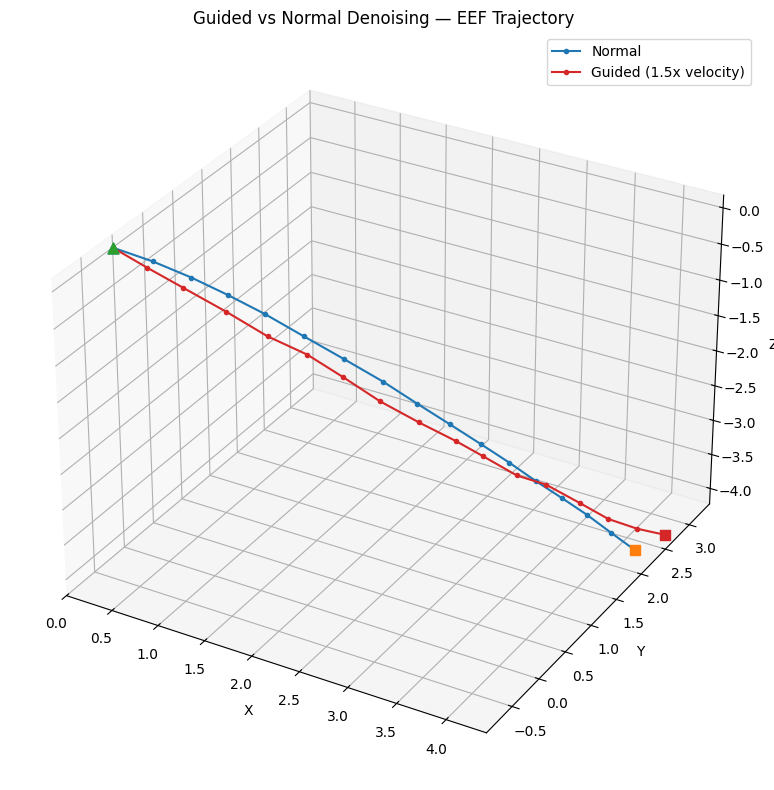

In [125]:
# Cell 14: Guided denoising — scale velocity by 1.5x
from functools import partial

def scale_velocity(actions, step_idx, velocity, scale=1.5):
    return velocity * scale

result_guided = lab.denoise(features, seed=42, guided_fn=partial(scale_velocity, scale=1.5))
result_normal = lab.denoise(features, seed=42)

viz_guide = TrajectoryVisualizer()
d_normal = lab.decode_raw_actions(result_normal.action_pred, features.states)
d_guided = lab.decode_raw_actions(result_guided.action_pred, features.states)

viz_guide.add_trajectory(d_normal, "Normal", color="tab:blue", eef_key=EEF_KEY)
viz_guide.add_trajectory(d_guided, "Guided (1.5x velocity)", color="tab:red", eef_key=EEF_KEY)

fig = viz_guide.plot_eef_3d(title="Guided vs Normal Denoising — EEF Trajectory")
plt.show()

In [126]:
# Cell 15: Raw denoising loop — full playground mode
seed = 42
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)

with torch.inference_mode():
    for t in range(num_steps):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        # === EDIT HERE: modify velocity, inject guidance, etc. ===
        # velocity = velocity * 1.0  # no-op example

        actions = actions + dt * velocity
        print(f"Step {t}: ts={ts.item()} action_norm={actions.float().norm():.4f} vel_norm={velocity.float().norm():.4f}")

raw_decoded = lab.decode_raw_actions(actions, features.states)
print("\nDone. Decoded keys:", list(raw_decoded.keys()))

Step 0: ts=0 action_norm=77.7739 vel_norm=30.7057
Step 1: ts=250 action_norm=77.1853 vel_norm=31.2027
Step 2: ts=500 action_norm=77.4565 vel_norm=31.9268
Step 3: ts=750 action_norm=78.6248 vel_norm=32.8372

Done. Decoded keys: ['end_effector_position', 'end_effector_rotation', 'gripper_close', 'base_motion', 'control_mode']


In [139]:
# Cell 16
seed = 42
num_steps = 1
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)

with torch.inference_mode():
    for t in range(num_steps):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        # === EDIT HERE: modify velocity, inject guidance, etc. ===
        # velocity = velocity * 1.0  # no-op example

        actions0 = actions + dt * velocity
        actions1 = dt * velocity
        print(f"Step {t}: ts={ts.item()} action_norm={actions.float().norm():.4f} vel_norm={velocity.float().norm():.4f}")

raw_decoded_one_shot_normal = lab.decode_raw_actions(actions0, features.states)
raw_decoded_one_shot_minus_noise = lab.decode_raw_actions(actions1, features.states)


#### 

seed = 100
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)

with torch.inference_mode():
    for t in range(num_steps):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        # === EDIT HERE: modify velocity, inject guidance, etc. ===
        # velocity = velocity * 1.0  # no-op example

        actions = actions + dt * velocity
        print(f"Step {t}: ts={ts.item()} action_norm={actions.float().norm():.4f} vel_norm={velocity.float().norm():.4f}")

raw_decoded_different_seed = lab.decode_raw_actions(actions, features.states)



seed = 100
num_steps = 1
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)

with torch.inference_mode():
    for t in range(num_steps):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        # === EDIT HERE: modify velocity, inject guidance, etc. ===
        # velocity = velocity * 1.0  # no-op example

        actions = actions + dt * velocity
        print(f"Step {t}: ts={ts.item()} action_norm={actions.float().norm():.4f} vel_norm={velocity.float().norm():.4f}")

raw_decoded_one_shot_different_seed = lab.decode_raw_actions(actions, features.states)



Step 0: ts=0 action_norm=79.1332 vel_norm=30.7057
Step 0: ts=0 action_norm=79.6871 vel_norm=32.5449
Step 1: ts=250 action_norm=79.0061 vel_norm=32.9037
Step 2: ts=500 action_norm=79.2336 vel_norm=33.4229
Step 3: ts=750 action_norm=80.4379 vel_norm=34.5927
Step 0: ts=0 action_norm=80.0586 vel_norm=32.5449


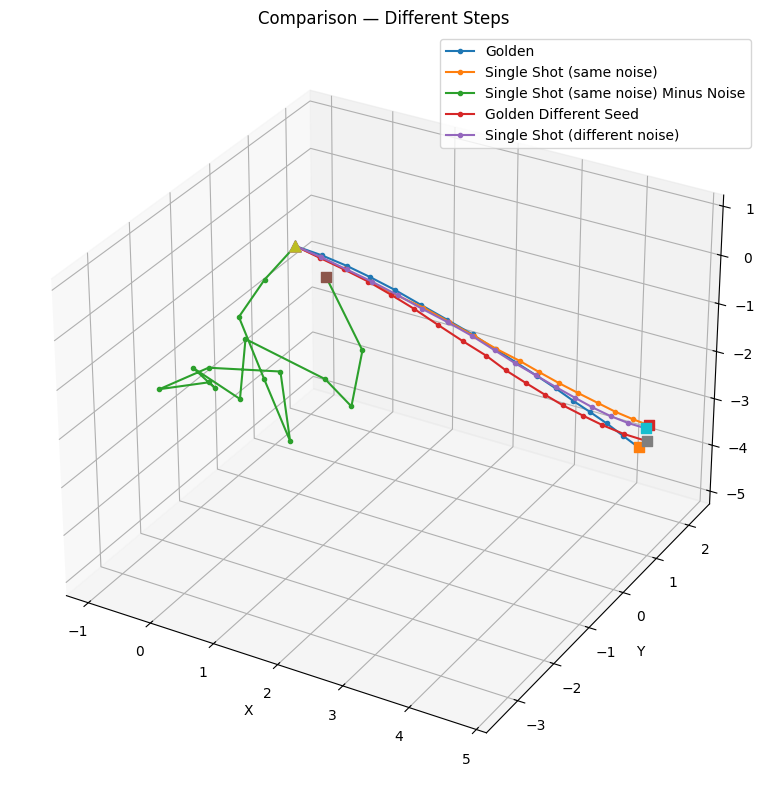

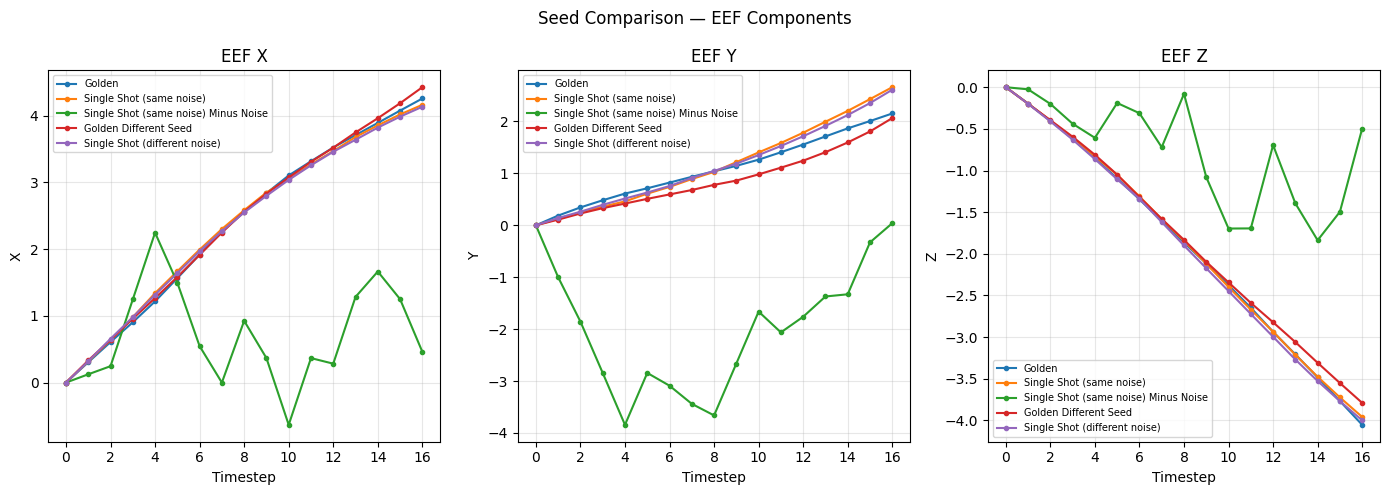

In [144]:
# Cell 17
viz_seeds = TrajectoryVisualizer()
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:gray"]

viz_seeds.add_trajectory(raw_decoded, f"Golden", color=colors[0], eef_key=EEF_KEY)
viz_seeds.add_trajectory(raw_decoded_one_shot_normal, f"Single Shot (same noise)", color=colors[1], eef_key=EEF_KEY)
viz_seeds.add_trajectory(raw_decoded_one_shot_minus_noise, f"Single Shot (same noise) Minus Noise", color=colors[2], eef_key=EEF_KEY)
viz_seeds.add_trajectory(raw_decoded_different_seed, f"Golden Different Seed", color=colors[3], eef_key=EEF_KEY)
viz_seeds.add_trajectory(raw_decoded_one_shot_different_seed, f"Single Shot (different noise)", color=colors[4], eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Comparison — Different Steps",
    show_gripper=False)

plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()


In [129]:
# Cell 18: Raw denoising loop — full playground mode
seed = 42
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)
print(actions.shape)

with torch.inference_mode():
    for t in range(10):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        if (ts > 800):
            ts = torch.tensor([800], device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_0 = lab.decode_raw_actions(actions, features.states)


#####
seed = 42
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)
print(actions.shape)

with torch.inference_mode():
    for t in range(6):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        if (ts > 800):
            ts = torch.tensor([800], device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_1 = lab.decode_raw_actions(actions, features.states)

#####
seed = 42
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)
print(actions.shape)

with torch.inference_mode():
    for t in range(6):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        if (ts >= 0):
            ts = torch.tensor([250], device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_2 = lab.decode_raw_actions(actions, features.states)

#####
seed = 42
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)
print(actions.shape)

with torch.inference_mode():
    for t in range(6):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        if (ts >= 0):
            ts = torch.tensor([500], device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_3 = lab.decode_raw_actions(actions, features.states)


#####
seed = 42
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

gen = torch.Generator(device=device).manual_seed(seed)
actions = torch.randn(
    (B, lab.action_horizon, lab.action_dim),
    dtype=vl_embeds.dtype, device=device, generator=gen,
)
print(actions.shape)

with torch.inference_mode():
    for t in range(6):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        if (ts >= 0):
            ts = torch.tensor([800], device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_4 = lab.decode_raw_actions(actions, features.states)




torch.Size([1, 50, 128])
Step 0: ts: 0
Step 1: ts: 250
Step 2: ts: 500
Step 3: ts: 750
Step 4: ts: 800
Step 5: ts: 800
Step 6: ts: 800


Step 7: ts: 800
Step 8: ts: 800
Step 9: ts: 800
torch.Size([1, 50, 128])
Step 0: ts: 0
Step 1: ts: 250
Step 2: ts: 500
Step 3: ts: 750
Step 4: ts: 800
Step 5: ts: 800
torch.Size([1, 50, 128])
Step 0: ts: 250
Step 1: ts: 250
Step 2: ts: 250
Step 3: ts: 250
Step 4: ts: 250
Step 5: ts: 250
torch.Size([1, 50, 128])
Step 0: ts: 500
Step 1: ts: 500
Step 2: ts: 500
Step 3: ts: 500
Step 4: ts: 500
Step 5: ts: 500
torch.Size([1, 50, 128])
Step 0: ts: 800
Step 1: ts: 800
Step 2: ts: 800
Step 3: ts: 800
Step 4: ts: 800
Step 5: ts: 800


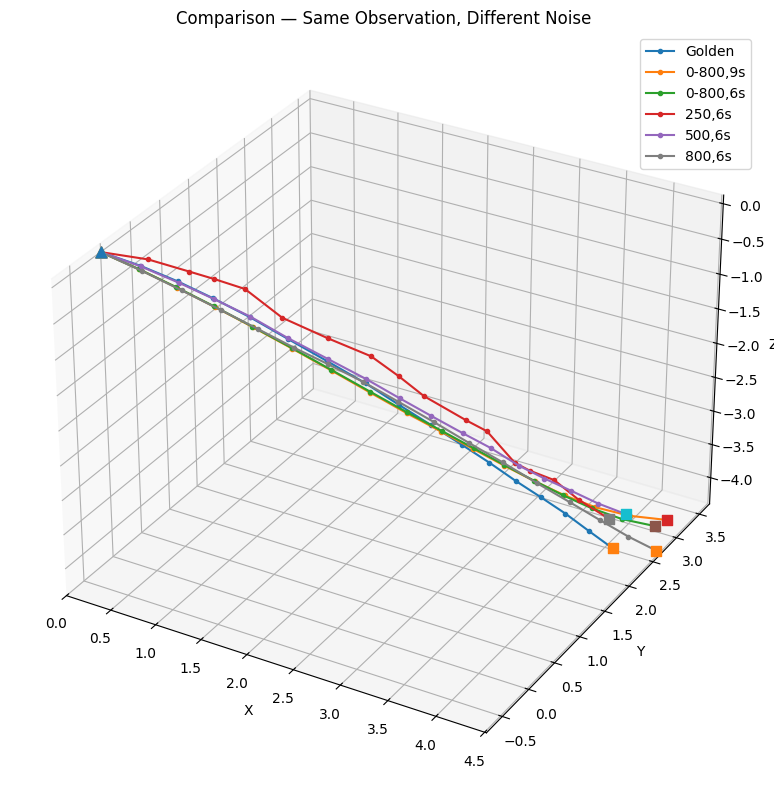

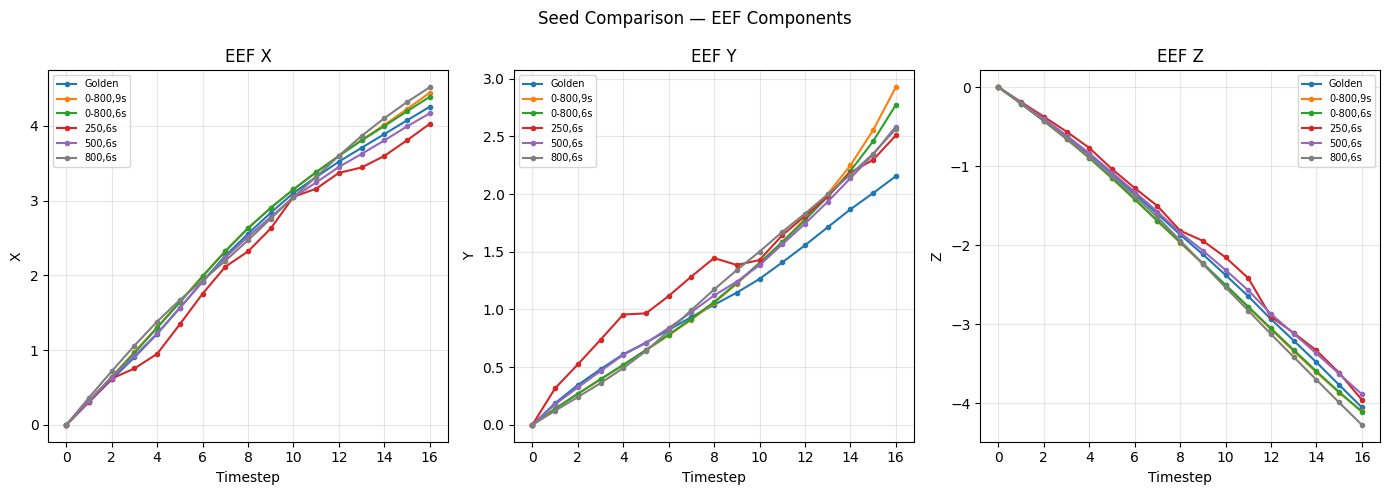

In [130]:
# Cell 19
viz_seeds = TrajectoryVisualizer()
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:gray"]

viz_seeds.add_trajectory(raw_decoded, f"Golden", color=colors[0], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_0, f"0-800,9s", color=colors[1], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_1, f"0-800,6s", color=colors[2], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_2, f"250,6s", color=colors[3], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_3, f"500,6s", color=colors[4], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_4, f"800,6s", color=colors[5], eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Comparison — Same Observation, Different Noise",
    show_gripper=False)

plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()


In [131]:
# Cell 20
num_steps = 4
dt = 1.0 / num_steps

vl_embeds = features.backbone_features
state_feats = features.state_features
emb_id = features.embodiment_id
bb_output = features.backbone_output
B = vl_embeds.shape[0]
device = vl_embeds.device

actions = 0.5 * torch.ones((1, 50, 128), device=device, dtype=vl_embeds.dtype)

with torch.inference_mode():
    for t in range(4):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_0 = lab.decode_raw_actions(actions, features.states)

#####

actions = -0.5 * torch.ones((1, 50, 128), device=device, dtype=vl_embeds.dtype)

with torch.inference_mode():
    for t in range(4):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_1 = lab.decode_raw_actions(actions, features.states)

####

sqrt3 = torch.sqrt(torch.tensor(3, device=device))
actions = torch.rand((1, 50, 128), device=device, dtype=vl_embeds.dtype) * 2 * sqrt3 - sqrt3

with torch.inference_mode():
    for t in range(4):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_2 = lab.decode_raw_actions(actions, features.states)

####

noise = torch.rand((1, 50, 128), device=device, dtype=vl_embeds.dtype) * 2 * sqrt3 - sqrt3
actions = noise

with torch.inference_mode():
    for t in range(4):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_3 = lab.decode_raw_actions(actions, features.states)

###

actions = -1 * noise

with torch.inference_mode():
    for t in range(4):
        t_cont = t / float(num_steps)
        t_disc = int(t_cont * lab.num_timestep_buckets)

        ts = torch.full((B,), t_disc, device=device)
        act_feat = lab.action_head.action_encoder(actions, ts, emb_id)

        if lab.action_head.config.add_pos_embed:  # True
            pos = torch.arange(act_feat.shape[1], dtype=torch.long, device=device)
            act_feat = act_feat + lab.action_head.position_embedding(pos).unsqueeze(0)

        sa = torch.cat((state_feats, act_feat), dim=1)

        if lab.action_head.config.use_alternate_vl_dit:  # True
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
                image_mask=bb_output.image_mask,
                backbone_attention_mask=bb_output.backbone_attention_mask,
            )
        else:
            out = lab.action_head.model(
                hidden_states=sa, encoder_hidden_states=vl_embeds, timestep=ts,
            )

        pred = lab.action_head.action_decoder(out, emb_id)
        velocity = pred[:, -lab.action_horizon:]

        actions = actions + dt * velocity
        print(f"Step {t}: ts: {ts.item()}")

decoded_exp_4 = lab.decode_raw_actions(actions, features.states)

Step 0: ts: 0
Step 1: ts: 250
Step 2: ts: 500
Step 3: ts: 750
Step 0: ts: 0
Step 1: ts: 250
Step 2: ts: 500
Step 3: ts: 750


Step 0: ts: 0
Step 1: ts: 250
Step 2: ts: 500
Step 3: ts: 750
Step 0: ts: 0
Step 1: ts: 250
Step 2: ts: 500
Step 3: ts: 750
Step 0: ts: 0
Step 1: ts: 250
Step 2: ts: 500
Step 3: ts: 750


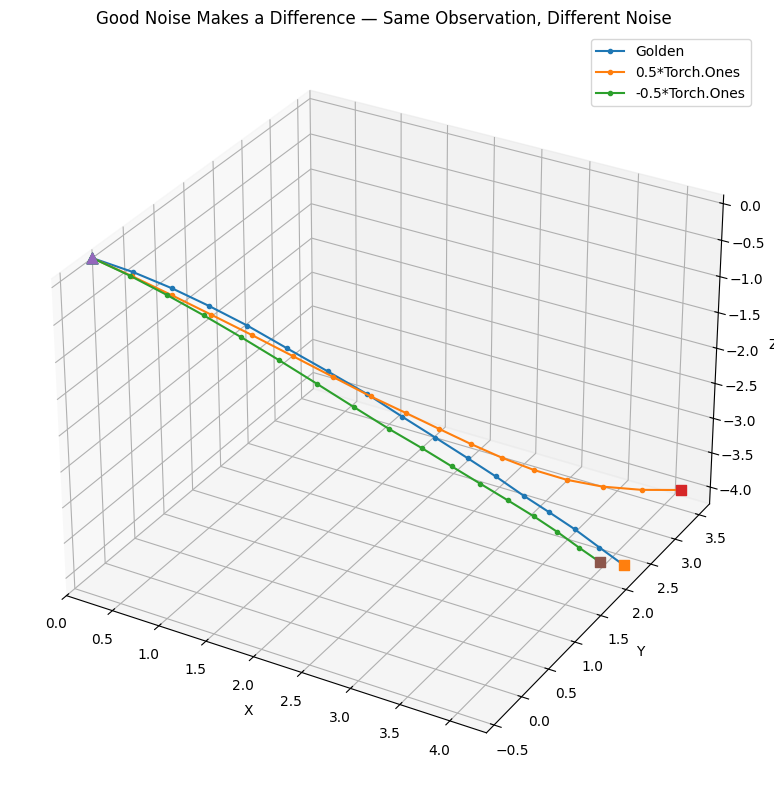

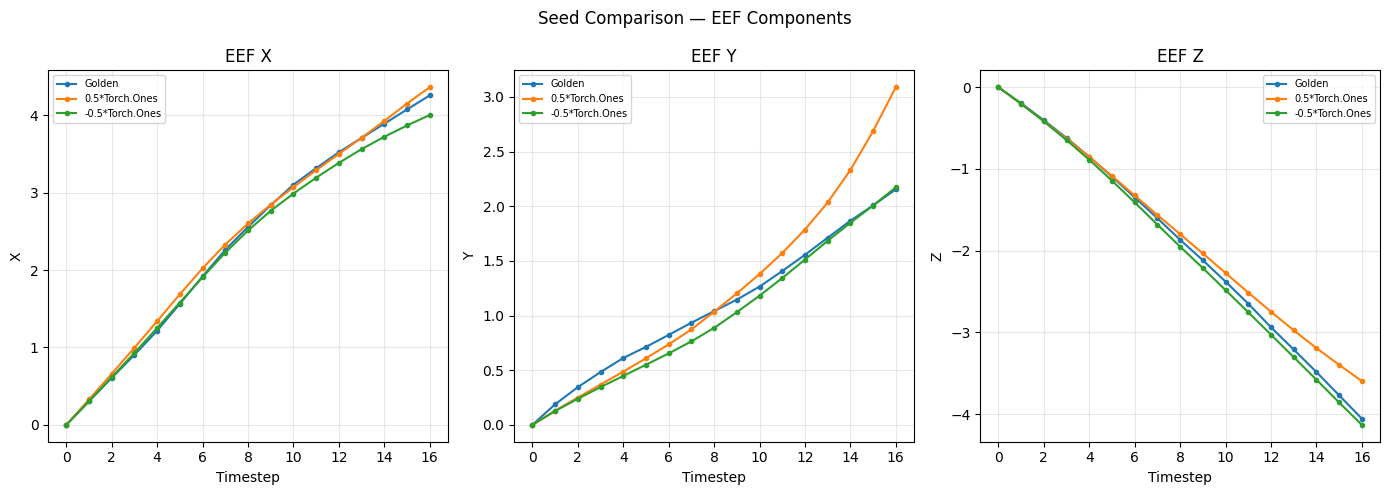

In [132]:
# Cell 21
viz_seeds = TrajectoryVisualizer()
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:pink"]

viz_seeds.add_trajectory(raw_decoded, f"Golden", color=colors[0], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_0, f"0.5*Torch.Ones", color=colors[1], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_1, f"-0.5*Torch.Ones", color=colors[2], eef_key=EEF_KEY)
# viz_seeds.add_trajectory(decoded_exp_2, f"UniformSample0", color=colors[3], eef_key=EEF_KEY)
# viz_seeds.add_trajectory(decoded_exp_3, f"UniformSample1", color=colors[4], eef_key=EEF_KEY)
# viz_seeds.add_trajectory(decoded_exp_4, f"UniformSample1*-1", color=colors[5], eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Good Noise Makes a Difference — Same Observation, Different Noise",
    show_gripper=False)

plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()

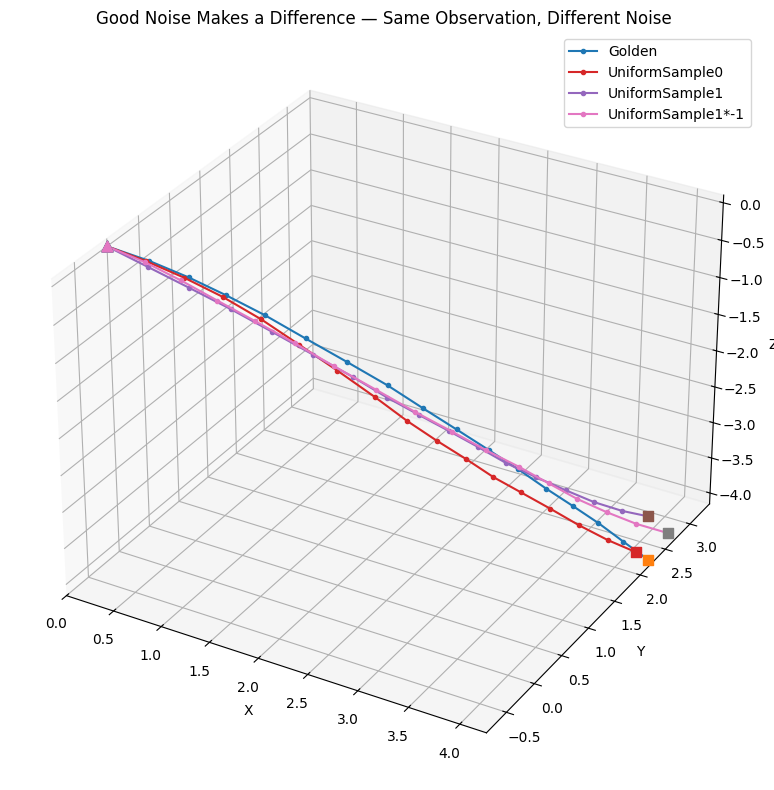

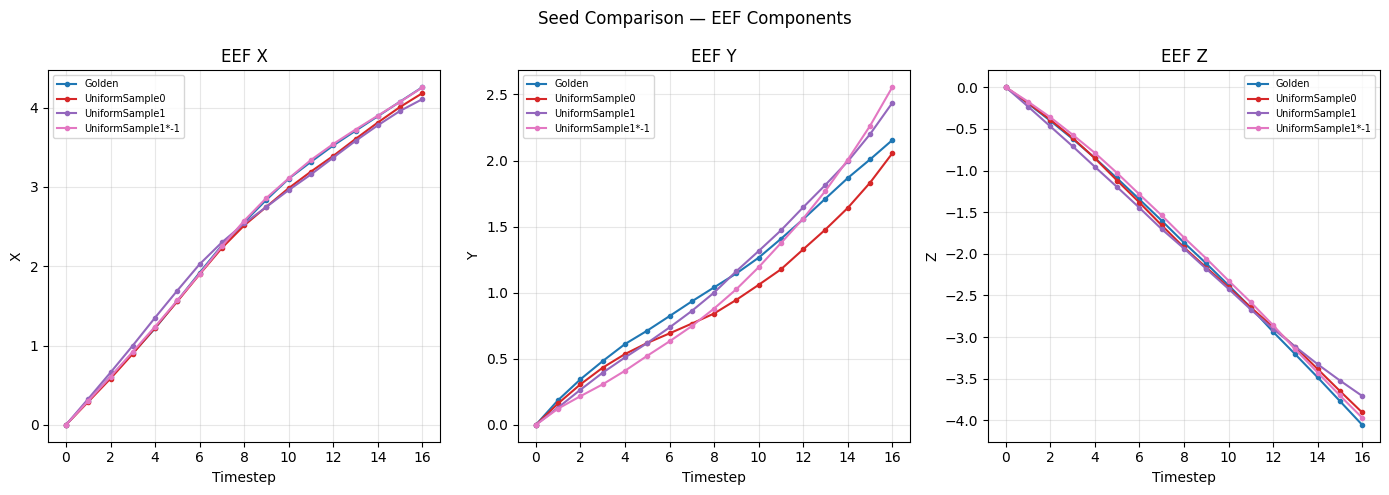

In [138]:
# Cell 22
viz_seeds = TrajectoryVisualizer()
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:pink"]

viz_seeds.add_trajectory(raw_decoded, f"Golden", color=colors[0], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_2, f"UniformSample0", color=colors[3], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_3, f"UniformSample1", color=colors[4], eef_key=EEF_KEY)
viz_seeds.add_trajectory(decoded_exp_4, f"UniformSample1*-1", color=colors[5], eef_key=EEF_KEY)

fig = viz_seeds.plot_eef_3d(title="Good Noise Makes a Difference — Same Observation, Different Noise",
    show_gripper=False)

plt.show()

fig2 = viz_seeds.plot_eef_components(title="Seed Comparison — EEF Components")
plt.show()

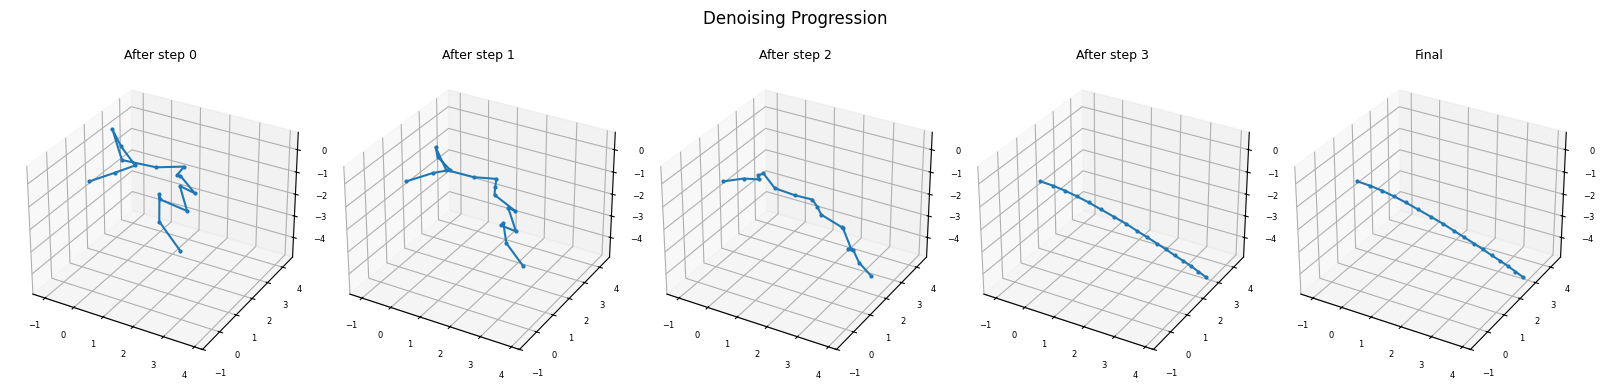

In [134]:
# Cell 23: Denoising progression visualization
result_for_prog = lab.denoise(features, seed=42)
fig = viz.plot_denoising_progression(result_for_prog, lab, eef_key=EEF_KEY)
plt.show()

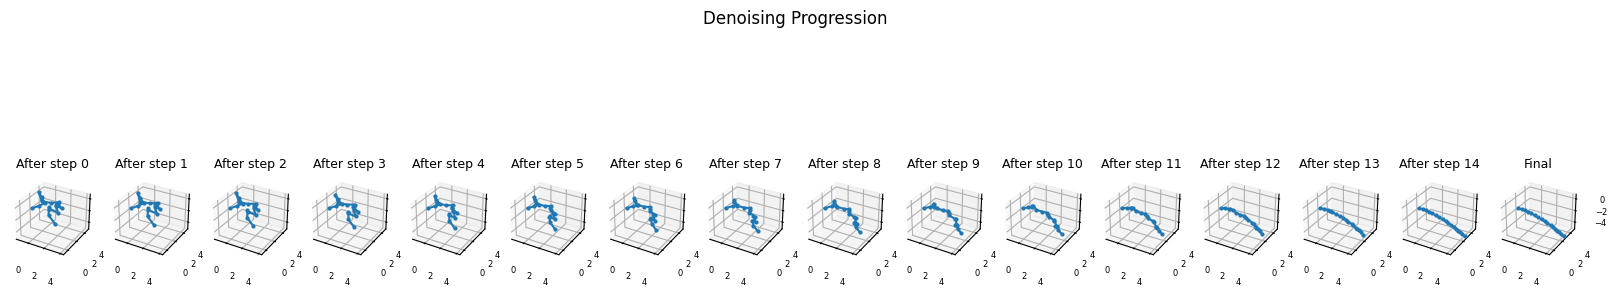

In [145]:
# Cell 24: Denoising progression visualization
result_for_prog = lab.denoise(features, num_steps=15, seed=42)
fig = viz.plot_denoising_progression(result_for_prog, lab, eef_key=EEF_KEY)
plt.show()

In [ ]:
# Cell 25: Export action chunk for replay in the simulator
#
# After experimenting with denoising strategies above, save your preferred
# action chunk for replay. Then run in the sim venv:
#
  # gr00t/eval/sim/robocasa/robocasa_uv/.venv/bin/python \
  #   scripts/denoising_lab/eval/interactive_rollout.py \
  #   --replay \
  #   --env-name robocasa_panda_omron/OpenDrawer_PandaOmron_Env \
  #   --obs-path /tmp/saved_observations/OpenDrawer0/ep000_step020.npz \
  #   --action-path /tmp/action_chunks/default.npz \
  #   --video-out /tmp/replay_default_exp.mp4

# decoded = decoded_exp

EXPORT_DIR = "/tmp/action_chunks"
os.makedirs(EXPORT_DIR, exist_ok=True)

# Export the default result (from cell 6)
export_path = os.path.join(EXPORT_DIR, "default.npz")
DenoisingLab.save_action_chunk(decoded, export_path)
print(f"Action chunk saved to: {export_path}")
print("Action keys:", list(decoded.keys()))
for k, v in decoded.items():
    print(f"  {k}: shape={v.shape}")

## Branching Rollout

Branch from a saved sim state: inject a custom action chunk, then continue
rolling out autonomously via the VLA server until success or episode budget
exhaustion.

This requires the model server to be running (Terminal 1) and uses the sim
venv to execute the rollout (same as `interactive_rollout.py`).

In [ ]:
# Cell 27: Save action chunk for branching rollout
BRANCH_ACTION_PATH = "/tmp/action_chunks/branch_experiment.npz"
os.makedirs(os.path.dirname(BRANCH_ACTION_PATH), exist_ok=True)

DenoisingLab.save_action_chunk(decoded, BRANCH_ACTION_PATH)
print(f"Action chunk saved to: {BRANCH_ACTION_PATH}")
print(f"Observation path: {OBS_PATH}")
print(f"\nReady for branching rollout.")

In [ ]:
# Cell 28: Launch branching rollout via subprocess (runs in sim venv)
#
# The branching rollout restores the MuJoCo sim state from the saved .npz,
# executes the custom action chunk, then continues autonomously via the
# VLA server until success or max_episode_steps.
import subprocess

BRANCH_OUTPUT_DIR = "/tmp/branching_results/exp_01"
ENV_NAME = "robocasa_panda_omron/OpenDrawer_PandaOmron_Env"
SIM_PYTHON = "gr00t/eval/sim/robocasa/robocasa_uv/.venv/bin/python"

cmd = [
    SIM_PYTHON,
    "scripts/denoising_lab/eval/branching_rollout.py",
    "--env-name", ENV_NAME,
    "--obs-path", OBS_PATH,
    "--action-path", BRANCH_ACTION_PATH,
    "--output-dir", BRANCH_OUTPUT_DIR,
    "--save-observations",
    "--max-episode-steps", "480",
]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True, cwd=REPO_ROOT)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)

In [ ]:
# Cell 29: Load and display branching results
import json

lineage_path = os.path.join(BRANCH_OUTPUT_DIR, "lineage.json")
with open(lineage_path) as f:
    lineage = json.load(f)

print(json.dumps(lineage, indent=2))